In [1]:
!pip install xgboost shap -q


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import shap
import matplotlib.pyplot as plt

In [3]:
moltbook = pd.read_pickle("../data/moltbook_final_mehmeh.pkl")

In [4]:
moltbook.columns

Index(['created_at', 'id', 'comment_count', 'score', 'submolt_name', 'post',
       'comment_existence', 'avg_early_sentiment', 'max_early_sentiment',
       'min_early_sentiment', 'safe_content', 'split'],
      dtype='object')

In [5]:
reddit = pd.read_csv("../data/reddit_metadata2.csv")

In [6]:
reddit.columns

Index(['id', 'author', 'created_utc', 'score', 'post', 'num_comments',
       'subreddit', 'comment_existence', 'avg_early_sentiment',
       'max_early_sentiment', 'min_early_sentiment', 'safe_content'],
      dtype='object')

In [7]:
reddit.head()

,id,author,created_utc,score,post,num_comments,subreddit,comment_existence,avg_early_sentiment,max_early_sentiment,min_early_sentiment,safe_content
0,1oz6fr,whiteknight521,1382450897,10,p-Zombies and the evolution of the human brain...,33,philosophy,1.0,0.136750,0.9338,-0.3182,p-Zombies and the evolution of the human brain...
1,gn98a,Daemonax,1302509777,4,Is anyone here familiar with Staines' arrows? ...,2,philosophy,0.2,-0.089950,-0.0772,-0.1027,Is anyone here familiar with Staines' arrows? ...
2,20vqw3,YaPaNiMaYu,1395293836,0,Consciousness Well I wish to expand on conscio...,8,philosophy,0.8,0.022988,0.9876,-0.8663,Consciousness Well I wish to expand on conscio...
3,1oxwu1,synesthesis,1382401005,13,"Time-consuming misdirection The first, and mos...",25,philosophy,1.0,0.294380,0.9982,-0.9210,"Time-consuming misdirection The first, and mos..."
4,grsg3,PhilosoDude,1303002528,0,The process of dialectic If the past few days ...,6,philosophy,0.6,0.389550,0.6416,0.1360,The process of dialectic If the past few days ...


In [8]:
reddit.rename(columns={"subreddit": "forum","num_comments": "comment_count" }, inplace=True)
moltbook.rename(columns={"submolt_name": "forum" }, inplace=True)


In [9]:
moltbook["created_at"] = pd.to_datetime(moltbook["created_at"])
reddit["created_at"] = pd.to_datetime(reddit["created_utc"], unit="s")

In [10]:
reddit["score"].describe()

count     7626.000000
mean        51.571728
std        854.429542
min          0.000000
25%          1.000000
50%          2.000000
75%          9.000000
max      48878.000000
Name: score, dtype: float64

In [11]:
reddit["label"] = 1
moltbook["label"] = 0

In [12]:
reddit.columns

Index(['id', 'author', 'created_utc', 'score', 'post', 'comment_count',
       'forum', 'comment_existence', 'avg_early_sentiment',
       'max_early_sentiment', 'min_early_sentiment', 'safe_content',
       'created_at', 'label'],
      dtype='object')

In [13]:
# reddit[['score', 'comment_count',
#        'forum', 'comment_existence', 'avg_early_sentiment',
#        'max_early_sentiment', 'min_early_sentiment', 'safe_content',
#        'created_at']]

In [14]:
df = pd.concat([reddit[['score', 'comment_count',
       'forum', 'comment_existence', 'avg_early_sentiment',
       'max_early_sentiment', 'min_early_sentiment', 
       'created_at',"label"]], moltbook[['score', 'comment_count',
       'forum', 'comment_existence', 'avg_early_sentiment',
       'max_early_sentiment', 'min_early_sentiment',
       'created_at',"label"]]], ignore_index=True)

In [15]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Initialize encoder, drop first category, return dense array
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the column (note: needs 2D input)
encoded_array = encoder.fit_transform(df[['forum']])

# Get feature names for the dummies
feature_names = encoder.get_feature_names_out(['forum'])

# Convert to DataFrame and combine
encoded_df = pd.DataFrame(encoded_array, 
                          columns=feature_names, 
                          index=df.index)

df_encoded = pd.concat([df, encoded_df], axis=1)

In [16]:
df_encoded.columns

Index(['score', 'comment_count', 'forum', 'comment_existence',
       'avg_early_sentiment', 'max_early_sentiment', 'min_early_sentiment',
       'created_at', 'label', 'forum_philosophy', 'forum_technology',
       'forum_todayilearned'],
      dtype='object')

In [17]:
df_encoded["created_at"] = pd.to_datetime(df_encoded["created_at"], utc=True)

In [18]:
df_encoded['hour'] = df_encoded['created_at'].dt.hour


In [19]:
df_encoded = df_encoded[['score' , 'comment_existence',
       'avg_early_sentiment', 'max_early_sentiment', 'min_early_sentiment',
    'forum_philosophy', 'forum_technology',
       'forum_todayilearned', 'hour',"label"]]

In [20]:

# Load Reddit embedding first
reddit_embedding = np.load('../data/reddit_features_full2.npy')  # adjust filename as needed
print(f"Reddit embedding shape: {reddit_embedding.shape}")

# Load Moltbook embedding
moltbook_embedding = np.load('../data/moltbook_features_full.npy')  # adjust filename as needed
print(f"Moltbook embedding shape: {moltbook_embedding.shape}")

# Stack them together (vertically - adding rows)
combined_embeddings = np.vstack([reddit_embedding, moltbook_embedding])
print(f"Combined shape: {combined_embeddings.shape}")

Reddit embedding shape: (7626, 1537)
Moltbook embedding shape: (7626, 1537)
Combined shape: (15252, 1537)


In [28]:
emb_df = pd.DataFrame(combined_embeddings, index=df_encoded.index)
emb_df.columns = [f'emb_{i}' for i in range(emb_df.shape[1])]
emb_df.to_pickle("../data/combined_embeddings.pkl")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import r2_score

target_col = 'score' 

if isinstance(combined_embeddings, np.ndarray):
    emb_df = pd.DataFrame(combined_embeddings, index=df_encoded.index)
    emb_df.columns = [f'emb_{i}' for i in range(emb_df.shape[1])]
    df_full = pd.concat([df_encoded, emb_df], axis=1)
else:
    # If combined_embeddings is already a pandas DataFrame
    df_full = pd.concat([df_encoded, combined_embeddings], axis=1)

df_full.to_pickle("../data/df_full_with_embeddings.pkl")  # Save the combined DataFrame for future use

# Drop the target and any other non-predictive metadata columns present in df_encoded
cols_to_drop = [target_col, 'id', 'author', 'created_utc', 'created_at', 'post', 'safe_content', 'split', 'source']
X = df_full.drop(columns=[col for col in cols_to_drop if col in df_full.columns])
y = df_full[target_col]
y_raw = df_encoded[target_col].clip(lower=0)
y = np.log1p(y_raw) 

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

# 4. Build the Random Forest Regression Model
model_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    max_features=0.8,  # Equivalent to XGBoost's colsample_bytree
    max_samples=0.8,   # Equivalent to XGBoost's subsample
    n_jobs=-1,         # Uses all available CPU cores for faster parallel training
    random_state=42
)

# 5. Train the model
# Random Forest does not use early stopping or an eval_set during the .fit() step
print("Training Random Forest...")
model_rf.fit(X_train, y_train)

# Optional: Check performance on the validation set
y_val_pred = model_rf.predict(X_val)
val_r2 = r2_score(y_val, y_val_pred)
print(f"R2 Score on Validation Set: {val_r2:.4f}")

# 6. Predict on the test set
y_pred = model_rf.predict(X_test)

# 7. Evaluate the model using R-squared (R2) score
r2 = r2_score(y_test, y_pred)
print(f"R2 Score on Test Set: {r2:.4f}")




# ==========================================
# DIAGNOSTICS: LEARNING CURVE
# ==========================================



Train shape: (10676, 1546)
Validation shape: (2288, 1546)
Test shape: (2288, 1546)
Training Random Forest...
R2 Score on Validation Set: -1.7597
R2 Score on Test Set: -5.4941


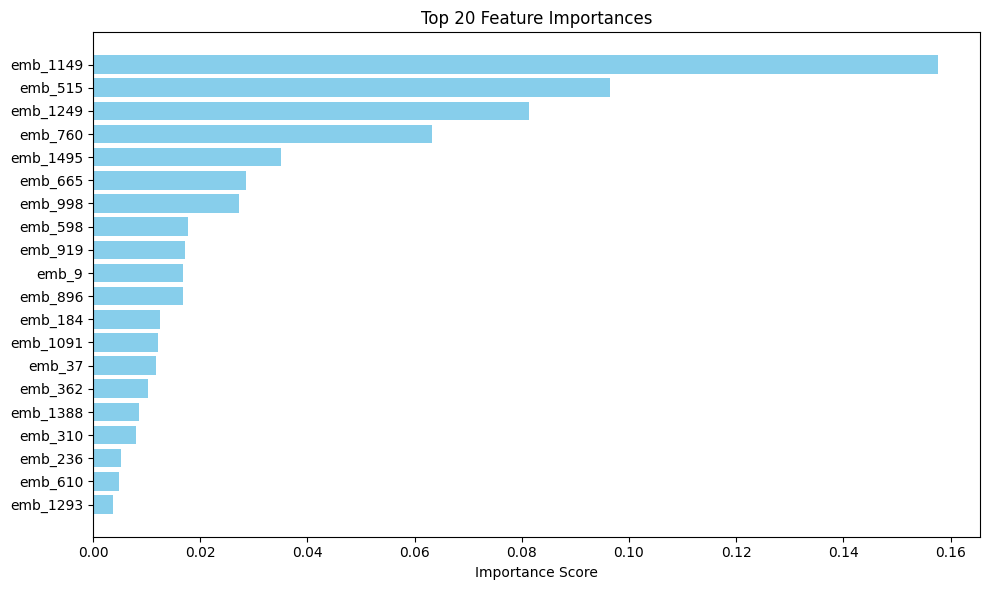

In [22]:
importances = model_rf.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot the top 20 features to avoid a massive, unreadable chart
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(feature_df['Feature'][:top_n][::-1], feature_df['Importance'][:top_n][::-1], color='skyblue')
plt.title(f'Top {top_n} Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Generating Learning Curve (this may take a moment)...


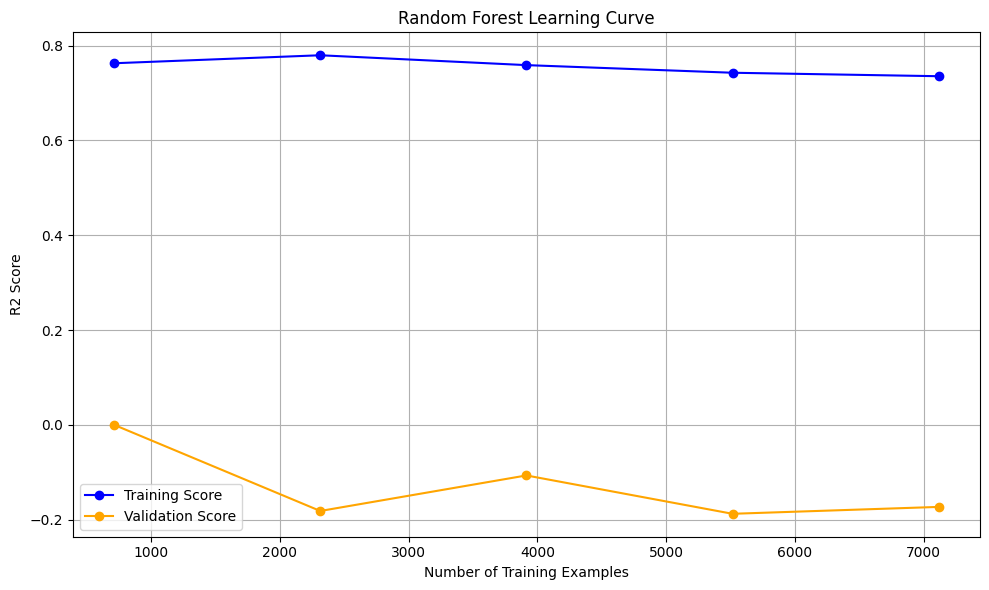

In [23]:
print("Generating Learning Curve (this may take a moment)...")
train_sizes = np.linspace(0.1, 1.0, 5) # Test at 10%, 32.5%, 55%, 77.5%, and 100% of data

train_sizes_abs, train_scores, val_scores = learning_curve(
    model_rf, X_train, y_train, 
    train_sizes=train_sizes, 
    cv=3, # 3-fold cross-validation
    scoring='r2', 
    n_jobs=-1
)

# Calculate means and standard deviations
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

# Plot the Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, train_scores_mean, 'o-', color='blue', label='Training Score')
plt.plot(train_sizes_abs, val_scores_mean, 'o-', color='orange', label='Validation Score')
plt.title('Random Forest Learning Curve')
plt.xlabel('Number of Training Examples')
plt.ylabel('R2 Score')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import umap

# 1. Prepare Base Features and Target
target_col = 'score' 
cols_to_drop = [target_col, 'id', 'author', 'created_utc', 'created_at', 'post', 'safe_content', 'split', 'source']
X_base = df_encoded.drop(columns=[col for col in cols_to_drop if col in df_encoded.columns])
y = df_encoded[target_col]
y_raw = df_encoded[target_col].clip(lower=0)
y = np.log1p(y_raw) 

# 2. Prepare Embeddings DataFrame separately
if isinstance(combined_embeddings, np.ndarray):
    emb_df = pd.DataFrame(combined_embeddings, index=df_encoded.index)
    emb_df.columns = [f'emb_{i}' for i in range(emb_df.shape[1])]
else:
    emb_df = combined_embeddings.copy()

# 3. Split the data 
# Splitting base features and embeddings simultaneously to keep rows aligned
X_base_train, X_base_temp, emb_train, emb_temp, y_train, y_temp = train_test_split(
    X_base, emb_df, y, test_size=0.30, random_state=42
)

X_base_val, X_base_test, emb_val, emb_test, y_val, y_test = train_test_split(
    X_base_temp, emb_temp, y_temp, test_size=0.50, random_state=42
)

# 4. Initialize and Apply UMAP to the Embeddings
n_components = 50 
print(f"Applying UMAP to reduce embeddings to {n_components} dimensions...")
print("(This may take a moment depending on the size of your dataset)")

# Initialize UMAP. random_state ensures reproducibility.
reducer = umap.UMAP(n_components=n_components, random_state=42)

# FIT ONLY ON TRAINING DATA to prevent data leakage, then transform all sets
emb_train_umap = reducer.fit_transform(emb_train)
emb_val_umap = reducer.transform(emb_val)
emb_test_umap = reducer.transform(emb_test)

# Convert back to DataFrames with proper indices so we can merge them
umap_cols = [f'umap_emb_{i}' for i in range(n_components)]
df_emb_train_umap = pd.DataFrame(emb_train_umap, index=X_base_train.index, columns=umap_cols)
df_emb_val_umap = pd.DataFrame(emb_val_umap, index=X_base_val.index, columns=umap_cols)
df_emb_test_umap = pd.DataFrame(emb_test_umap, index=X_base_test.index, columns=umap_cols)

# 5. Recombine the UMAP embeddings with the base features
X_train_final = pd.concat([X_base_train, df_emb_train_umap], axis=1)
X_val_final = pd.concat([X_base_val, df_emb_val_umap], axis=1)
X_test_final = pd.concat([X_base_test, df_emb_test_umap], axis=1)

print(f"Final Training Data Shape: {X_train_final.shape}")

# 6. Build and Train the Random Forest Regression Model
print("Training Random Forest...")
model_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    max_features=0.8,
    max_samples=0.8,
    n_jobs=-1,
    random_state=42
)

model_rf.fit(X_train_final, y_train)

# 7. Evaluate the model
y_pred = model_rf.predict(X_test_final)
r2 = r2_score(y_test, y_pred)

print("--- Results ---")
print(f"R2 Score on Test Set: {r2:.4f}")

In [24]:
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import r2_score
# import xgboost as xgb

# # 1. Combine the dataframes
# # If combined_embeddings is a numpy array, convert it to a DataFrame first
# if isinstance(combined_embeddings, np.ndarray):
#     emb_df = pd.DataFrame(combined_embeddings, index=df_encoded.index)
#     emb_df.columns = [f'emb_{i}' for i in range(emb_df.shape[1])]
#     df_full = pd.concat([df_encoded, emb_df], axis=1)
# else:
#     # If combined_embeddings is already a pandas DataFrame
#     df_full = pd.concat([df_encoded, combined_embeddings], axis=1)

# # 2. Define features (X) and target (y)
# target_col = 'score' 

# # Drop the target and any other non-predictive metadata columns present in df_encoded
# cols_to_drop = [target_col, 'id', 'author', 'created_utc', 'created_at', 'post', 'safe_content', 'split', 'source']
# X = df_full.drop(columns=[col for col in cols_to_drop if col in df_full.columns])
# y = df_full[target_col]

# # 3. Split the data: Train (70%), Val (15%), Test (15%)
# # First split off 30% for the combined validation and test sets
# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# # Second split the 30% temporary set in half to get 15% validation and 15% test
# X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# print(f"Train shape: {X_train.shape}")
# print(f"Validation shape: {X_val.shape}")
# print(f"Test shape: {X_test.shape}")

# # 4. Build the XGBoost Regression Model
# model_xgb = xgb.XGBRegressor(
#     n_estimators=500,
#     learning_rate=0.05,
#     max_depth=6,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     early_stopping_rounds=20,
#     eval_metric='rmse'
# )

# # 5. Train the model using the training set and validate on the validation set
# model_xgb.fit(
#     X_train, y_train,
#     eval_set=[(X_val, y_val)],
#     verbose=50  # Prints progress every 50 trees
# )

# # 6. Predict on the test set
# y_pred = model_xgb.predict(X_test)

# # 7. Evaluate the model using R-squared (R2) score
# r2 = r2_score(y_test, y_pred)
# print(f"R2 Score on Test Set: {r2:.4f}")

In [25]:
# from sklearn.preprocessing import StandardScaler
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader, TensorDataset

# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
# X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# # 4. Scale the features (Important for Neural Networks)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled = scaler.transform(X_val)
# X_test_scaled = scaler.transform(X_test)

# # 5. Convert to PyTorch Tensors
# X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
# y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

# X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
# y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

# X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
# y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# # 6. Create DataLoaders
# batch_size = 64
# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# # 7. Define the Neural Network Architecture
# class ScoreRegressor(nn.Module):
#     def __init__(self, input_dim):
#         super(ScoreRegressor, self).__init__()
#         self.network = nn.Sequential(
#             nn.Linear(input_dim, 256),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(256, 128),
#             nn.ReLU(),
#             nn.Dropout(0.2),
#             nn.Linear(128, 64),
#             nn.ReLU(),
#             nn.Linear(64, 1) # Single output for regression
#         )
        
#     def forward(self, x):
#         return self.network(x)

# input_dim = X_train_scaled.shape[1]
# model = ScoreRegressor(input_dim)

# # 8. Define Loss Function and Optimizer
# criterion = nn.MSELoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# # 9. Training Loop
# epochs = 50
# best_val_loss = float('inf')

# for epoch in range(epochs):
#     model.train()
#     train_loss = 0.0
#     for batch_X, batch_y in train_loader:
#         optimizer.zero_grad()
#         predictions = model(batch_X)
#         loss = criterion(predictions, batch_y)
#         loss.backward()
#         optimizer.step()
#         train_loss += loss.item() * batch_X.size(0)
        
#     train_loss /= len(train_loader.dataset)
    
#     # Validation step
#     model.eval()
#     val_loss = 0.0
#     with torch.no_grad():
#         for batch_X, batch_y in val_loader:
#             predictions = model(batch_X)
#             loss = criterion(predictions, batch_y)
#             val_loss += loss.item() * batch_X.size(0)
            
#     val_loss /= len(val_loader.dataset)
    
#     if (epoch + 1) % 5 == 0:
#         print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# # 10. Predict on the Test Set and Calculate R2 Score
# model.eval()
# with torch.no_grad():
#     y_test_pred = model(X_test_tensor)

# # Convert back to numpy arrays for sklearn metrics
# y_test_pred_np = y_test_pred.numpy()
# y_test_np = y_test_tensor.numpy()

# r2 = r2_score(y_test_np, y_test_pred_np)
# print(f"\\nR2 Score on Test Set: {r2:.4f}")

In [26]:
import copy
y_raw = df_full[target_col].clip(lower=0)
y = np.log1p(y_raw) 

# 3. Split the data: Train (70%), Val (15%), Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# 4. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 5. Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# 6. Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 7. Define the Neural Network Architecture
class ScoreRegressor(nn.Module):
    def __init__(self, input_dim):
        super(ScoreRegressor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.network(x)

input_dim = X_train_scaled.shape[1]
model = ScoreRegressor(input_dim)

# 8. Define Loss Function and Optimizer
criterion = nn.HuberLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 9. Training Loop with Epoch-level R2 calculation
epochs = 50
best_val_loss = float('inf')
best_model_weights = None
patience = 10
epochs_no_improve = 0

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0
    train_preds = []
    train_targets = []
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * batch_X.size(0)
        
        # Collect predictions and targets for R2 calculation
        train_preds.extend(predictions.detach().cpu().numpy())
        train_targets.extend(batch_y.cpu().numpy())
        
    train_loss /= len(train_loader.dataset)
    
    # Calculate Train R2 on the raw scale
    train_preds_raw = np.expm1(np.array(train_preds))
    train_targets_raw = np.expm1(np.array(train_targets))
    train_r2 = r2_score(train_targets_raw, train_preds_raw)
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_targets = []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item() * batch_X.size(0)
            
            # Collect predictions and targets for R2 calculation
            val_preds.extend(predictions.cpu().numpy())
            val_targets.extend(batch_y.cpu().numpy())
            
    val_loss /= len(val_loader.dataset)
    
    # Calculate Val R2 on the raw scale
    val_preds_raw = np.expm1(np.array(val_preds))
    val_targets_raw = np.expm1(np.array(val_targets))
    val_r2 = r2_score(val_targets_raw, val_preds_raw)
    
    # Print metrics for EVERY epoch
    print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train R2: {train_r2:.4f} | Val R2: {val_r2:.4f}")
        
    # Early Stopping logic based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}! Restoring best weights.")
            break

# Load the best weights back into the model before evaluating test set
model.load_state_dict(best_model_weights)

# 10. Predict on the Test Set and Calculate Final R2 Score
model.eval()
with torch.no_grad():
    y_test_pred_log = model(X_test_tensor).numpy()

# Convert back to raw scores
y_test_pred_raw = np.expm1(y_test_pred_log)
y_test_raw = np.expm1(y_test_tensor.numpy())

test_r2 = r2_score(y_test_raw, y_test_pred_raw)
print(f"\nFinal R2 Score on Test Set (Raw Scale): {test_r2:.4f}")

NameError: name 'torch' is not defined

Train shape: (10676, 1546)
Validation shape: (2288, 1546)
Test shape: (2288, 1546)
Training Random Forest...
R2 Score on Validation Set: 0.4225
R2 Score on Test Set: 0.3977

--- Feature Importances ---


NameError: name 'feature_importances' is not defined

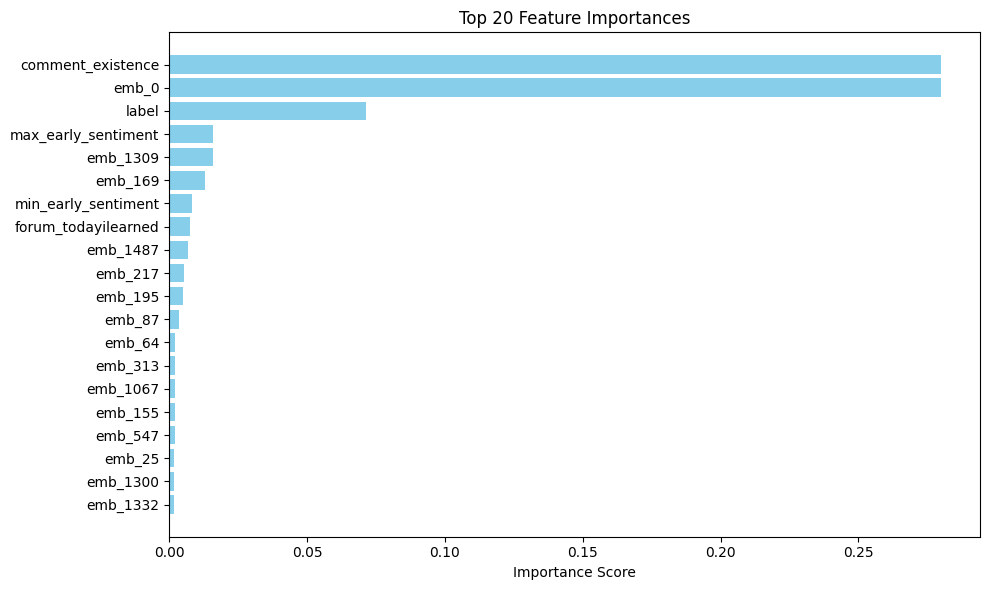

Generating Learning Curve (this may take a moment)...
